# Matplotlib & Seaborn Revision

## Objective
Re-ativate visualization fundamentals. By the end, I should be able to:
- Choose the right plot for the right question
- Customize plots (labels, colors, subplots)
- Read a plot and extract insight, not just draw it

## Topics Covered
- Histogram, Box plot, Bar chart, Scatter plot
- Heatmap (correlation), Pairplot
- Subplots and figure sizing
- When to use Matplotlib vs Seaborn

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup complete.")

Setup complete.


## 1. Histogram — Distribution of a single variable
**Question it answers:** How is this variable distributed?

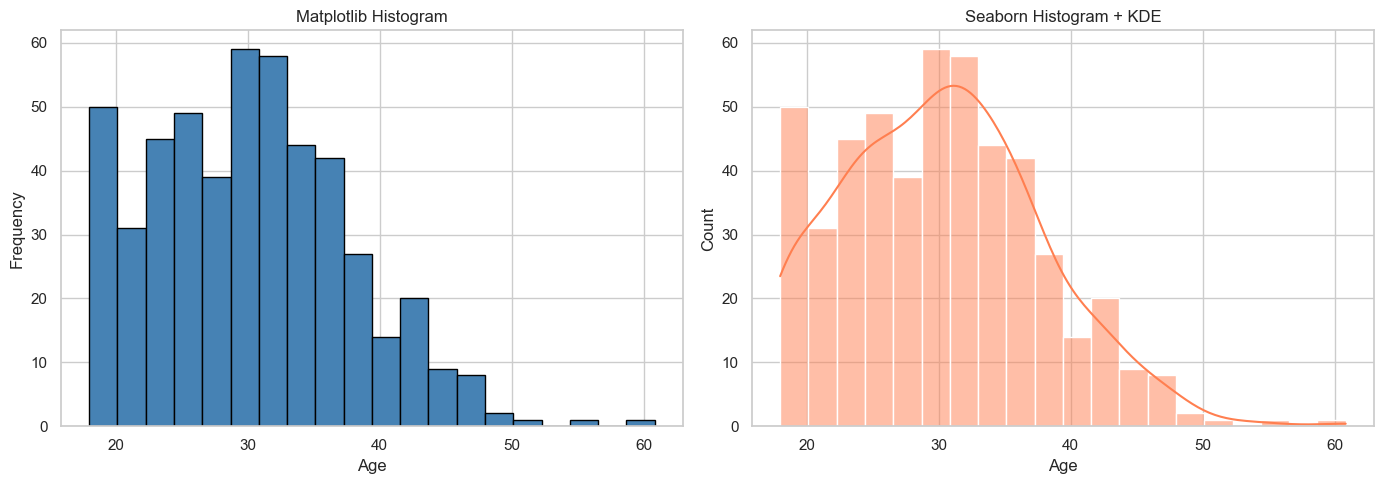

In [41]:
# Generate synthetic data
np.random.seed(42)
ages = np.random.normal(loc=30, scale=8, size=500)
ages = np.clip(ages, 18, 65)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matplotlib version
axes[0].hist(ages, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title("Matplotlib Histogram")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# Seaborn version (with KDE overlay)
sns.histplot(ages, bins=20, kde=True, ax=axes[1], color='coral')
axes[1].set_title("Seaborn Histogram + KDE")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

### Observation
- Matplotlib gives raw control; Seaborn adds KDE by default.
- The distribution is roughly normal (as expected from `np.random.normal`).
- KDE helps see the shape smoothly — useful when bins are arbitrary.

## 2. Box Plot — Spread + outliers
**Question it answers:** What's the spread, median, and are there outliers?

C:\Users\siris\AppData\Local\Temp\ipykernel_18196\630804804.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sal, x='Department', y='Salary', palette='Set2')


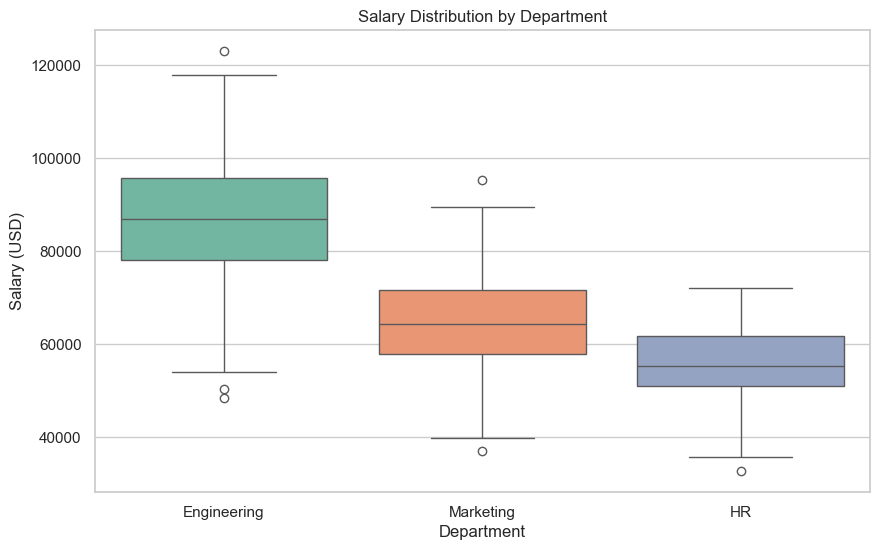

In [42]:
# Simulate salaries across 3 departments
np.random.seed(1)
salaries = {
    'Engineering': np.random.normal(85000, 15000, 200),
    'Marketing':   np.random.normal(65000, 10000, 150),
    'HR':          np.random.normal(55000, 8000, 100),
}

df_sal = pd.DataFrame({
    'Department': np.repeat(list(salaries.keys()), [len(v) for v in salaries.values()]),
    'Salary': np.concatenate(list(salaries.values()))
})

sns.boxplot(data=df_sal, x='Department', y='Salary', palette='Set2')
plt.title("Salary Distribution by Department")
plt.ylabel("Salary (USD)")
plt.show()

### Observation
- Engineering has the widest IQR and highest median.
- HR has the tightest spread.
- Box plots are ideal for comparing distributions across categories.

## 3. Bar Chart — Comparing categories
**Question it answers:** How do categories compare on a metric?

C:\Users\siris\AppData\Local\Temp\ipykernel_18196\4162808573.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_sal.index, y=avg_sal.values, palette='viridis')


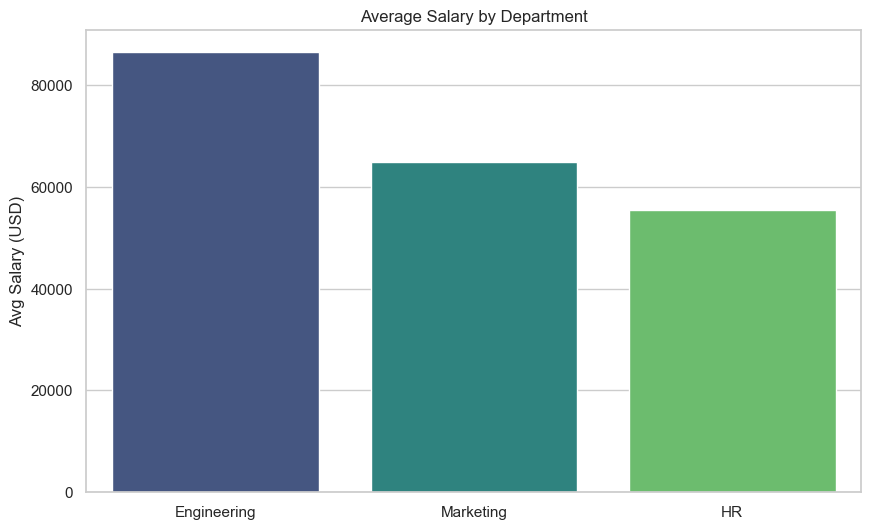

In [43]:
# Average salary per department
avg_sal = df_sal.groupby('Department')['Salary'].mean().sort_values(ascending=False)

sns.barplot(x=avg_sal.index, y=avg_sal.values, palette='viridis')
plt.title("Average Salary by Department")
plt.ylabel("Avg Salary (USD)")
plt.xlabel("")
plt.show()

## 4. Scatter Plot — Relationship between two variables
**Question it answers:** Is there a relationship between X and Y?

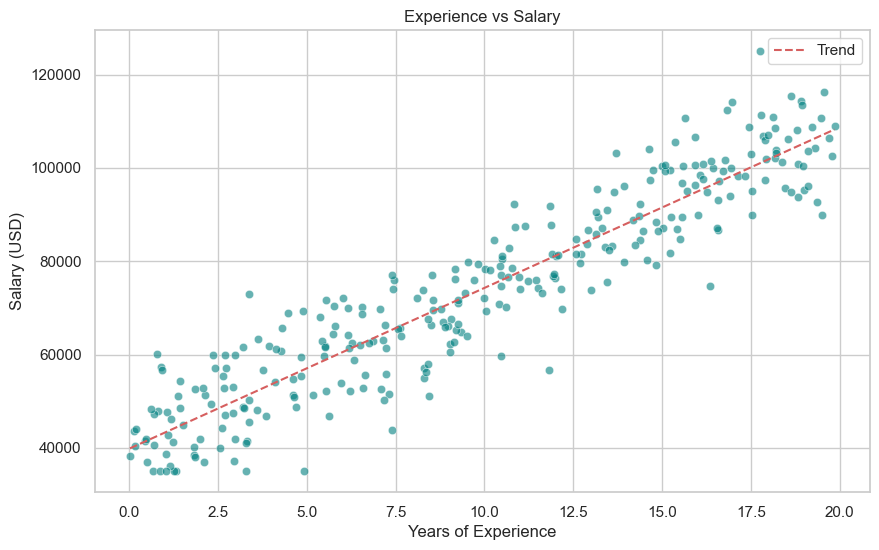

In [44]:
# Experience vs Salary (positive correlation with noise)
np.random.seed(7)
experience = np.random.uniform(0, 20, 300)
salary = 40000 + 3500 * experience + np.random.normal(0, 8000, 300)
salary = np.clip(salary, 35000, None)

sns.scatterplot(x=experience, y=salary, alpha=0.6, color='teal')
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (USD)")

# Add a trend line
z = np.polyfit(experience, salary, 1)
p = np.poly1d(z)
plt.plot(np.sort(experience), p(np.sort(experience)), 'r--', label='Trend')
plt.legend()
plt.show()

### Observation
- Clear positive correlation between experience and salary.
- Scatter plots are the go-to for bivariate relationships.
- Always add a trend line to make the relationship obvious.

## 5. Correlation Heatmap
**Question it answers:** Which variables are correlated with each other?

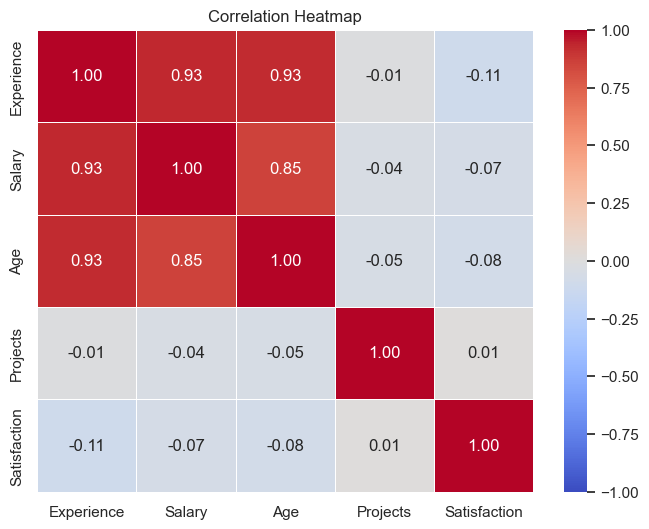

In [45]:
# Build a small multi-feature DataFrame
np.random.seed(42)
df_corr = pd.DataFrame({
    'Experience': experience,
    'Salary': salary,
    'Age': experience * 1.2 + np.random.normal(25, 3, 300),
    'Projects': np.random.poisson(5, 300),
    'Satisfaction': np.random.uniform(1, 10, 300)
})

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

### Observation
- Experience and Age are strongly correlated (expected, since Age was derived from Experience).
- Satisfaction shows weak correlation with everything — good.
- Heatmaps help spot multicollinearity before modeling.

## 7. Subplots — Telling a story with multiple plots

C:\Users\siris\AppData\Local\Temp\ipykernel_18196\3944674640.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sal, x='Department', y='Salary', ax=axes[0, 1], palette='Set3')


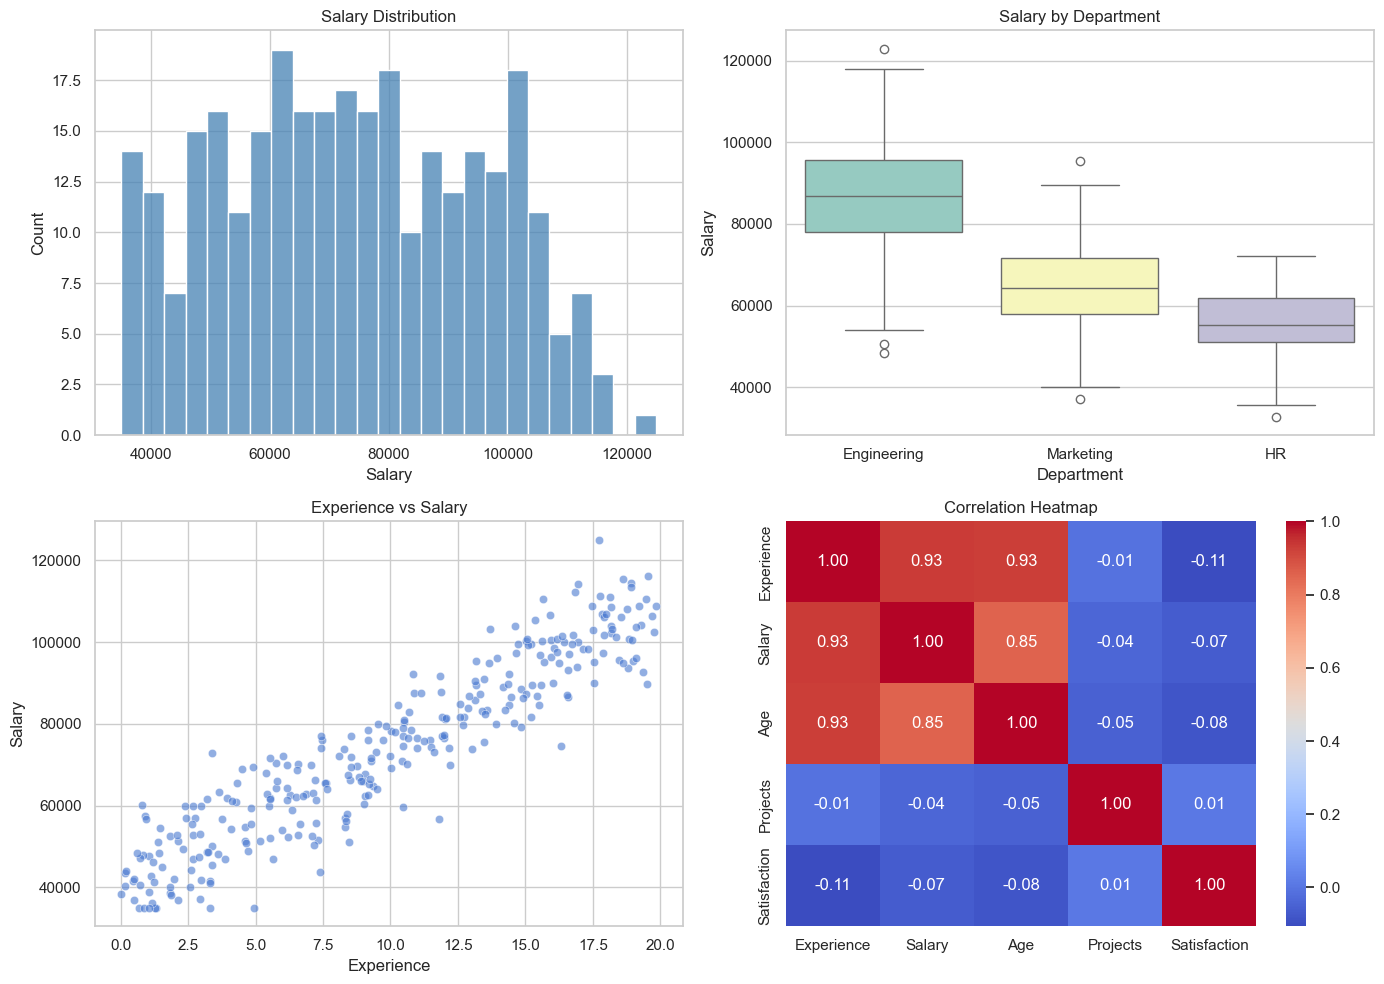

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_corr['Salary'], bins=25, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title("Salary Distribution")

sns.boxplot(data=df_sal, x='Department', y='Salary', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title("Salary by Department")

sns.scatterplot(data=df_corr, x='Experience', y='Salary', 
                ax=axes[1, 0], alpha=0.6)
axes[1, 0].set_title("Experience vs Salary")

sns.heatmap(df_corr[['Experience', 'Salary', 'Age', 'Projects', 'Satisfaction']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()